# Analyze SHRECC electricity databases with `NewDatabase`

This expanded notebook explores the harmonized historical and prospective workflow, including source configuration, graph solving, physical volumes, normalized consumption mixes, activity mapping, fallback diagnostics, cutoff tables, and Brightway database writing.

For the shortest path from configuration to a written database, start with [1_shrecc_get_started.ipynb](1_shrecc_get_started.ipynb).

In [1]:
from time import perf_counter

import bw2data as bd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import numpy as np
import pandas as pd
from IPython.display import display

from shrecc import NewDatabase

## Configuration

You can set `years = [2025, 2035, 2040, 2050]` to create all mapped tables. Each year is automatically linked to the adequate source (historic years to the Energy Charts API, prospective years to the TYNDP data) The month, day, and hour selection is transferred automatically to each requested year.

### Basic configuration
Common to all database creation.

In [2]:
# Geographical and temporal scope of the inventories you want to create
countries  = ["ES", "FR", "DE", "IT", "PT", "BE", "NL", "LU", "AT", "CH"]
time_range = ["2040-06-01 00:00:00", "2040-06-30 23:00:00"]
hour_range = [10, 14]
# ...this will produce grid mix inventories specifically for the month of June around noon (10:00-14:00)  

# Brightway instructions
project_name   = "SHRECCei311"
my_db_name     = "shrecc_june_noon"
write_database = True  # Set to True only after inspecting the mapped tables.


### Prospective database additional info
These parameters are required because:
- you can create several possible prospective databases (depending on year, climate year, scenario)
- you need to explicitly declare which (existing) prospective database will be used for each year's matching

The TYNDP scenarios used as a source for the prospective data are described in the following visual.

![tyndp scenarios](tyndp_story_lines_screenshot.png)

In [3]:
# If prospective, TYNDP scenario, climate year, and year
scenario     = "DE" # DE, NT, GA
climate_year = 2009 # 1995, 2008, 2009
years        = [2025, 2035, 2040, 2050]  # Use [2035, 2040, 2050] for the complete run. DE/GA: 2035, 2040, 2050; NT: 2030, 2040

# Specifying multiple years here will supersede the year declared in `time_range`

# Last thing is to declare the databases you match against for each year
# TODO: create premise databases on-the-fly if they do not exist?
bg_db_name = {
    2025: "ecoinvent-3.11-cutoff",
    2035: "ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2035 2026-07-10",
    2040: "ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2040 2026-07-10",
    2050: "ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2050 2026-07-10",
}

## Brightway preflight

Creating tables does not modify any local Brightway database. The preflight only verifies that the configured project and year-specific premise databases are available.

In [4]:
bd.projects.set_current(project_name)

configured_backgrounds = {year: bg_db_name[year] for year in years}
missing_backgrounds = {
    year: name
    for year, name in configured_backgrounds.items()
    if name not in bd.databases
}
if missing_backgrounds:
    raise ValueError(f"Missing premise databases in {project_name!r}: {missing_backgrounds}")

# Display the databases against which each year will be mapped
pd.Series(configured_backgrounds, name="premise database").rename_axis("year").to_frame()

,premise database
year,
2025,ecoinvent-3.11-cutoff
2035,ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2035 2...
2040,ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2040 2...
2050,ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2050 2...


## Configure the pipeline

`source="auto"` selects TYNDP for these prospective years. `strict=False` permits the location fallback while preserving the mapped source technology.

In [5]:
# A lot of arguments here are optional, they are exposed for transparency

elec_noon_june = NewDatabase(
    scenario=scenario,
    years=years,
    climate_year=climate_year,
    bg_db_name=configured_backgrounds,
    iam="remind-eu",
    my_db_name=my_db_name,
    countries=countries,
    time_range=time_range,
    hour_range=hour_range,
    project_name=project_name,
    source="auto",
    cutoff=1e-3,
    include_cutoff=True,
    strict=False,
    network=True,
    zero_consumption="month_hour_average",
    include_consumption_mix_volume=True,
    check=True,
    verbose=True,
)

elec_noon_june

NewDatabase(years=[2025, 2035, 2040, 2050], sources={2025:energy_charts, 2035:tyndp, 2040:tyndp, 2050:tyndp})

In [6]:
pd.DataFrame(
    {
        "source": elec_noon_june.sources,
        "background database": elec_noon_june.background_databases,
        "output database": elec_noon_june.database_names,
    }
).rename_axis("year")

,source,background database,output database
year,,,
2025,energy_charts,ecoinvent-3.11-cutoff,shrecc_june_noon_2025
2035,tyndp,ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2035 2...,shrecc_june_noon_2035
2040,tyndp,ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2040 2...,shrecc_june_noon_2040
2050,tyndp,ei_cutoff_3.11_remind-eu_SSP2-PkBudg650_2050 2...,shrecc_june_noon_2050


## Create mapped tables

This is the computational step. It may download and cache TYNDP source files, solve the selected hourly systems, map activities, and create the cutoff tables. It still does not write a Brightway database.

In [7]:
started = perf_counter()
elec_noon_june.create()
elapsed = perf_counter() - started
print(f"Created {len(years)} mapped table(s) in {elapsed:,.1f} seconds.")

Creating energy_charts electricity mix for 2025


C:\Users\Gibon\AppData\Local\Temp\ipykernel_33048\1865320616.py:2: UserWarning: Energy Charts activity mapping gaps for 2025 were assigned to source-country high-voltage production mixes. Mean fallback share by consumer: NL 72.4%, BE 12.1%, LU 4.6%, IT 4.5%, CH 3.6%. Largest source-technology gaps: NL/Others 70.3%, BE/Others 4.2%, IT/Others 4.2%, CH/Others 3.2%, LU/Waste non-renewable 1.9%. See mapping_report(2025) for the full report.
  elec_noon_june.create()


Creating tyndp electricity mix for 2035
2026-07-23 10:26:01 Loading TYNDP pickle files
2026-07-23 10:26:02 Parsing hourly datetime index
2026-07-23 10:26:02 Loading technology and country mappings
2026-07-23 10:26:02 Aggregating hourly production by country and technology


D:\shrecc_project\shrecc\shrecc\tyndp.py:1159: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  production = production.groupby(


2026-07-23 10:26:02 Aggregating hourly trade to positive directional country flows


...

2026-07-23 10:26:07 Combining production and trade into Z_gross
2026-07-23 10:26:07 Built Z_gross with shape (8736, 547)
2026-07-23 10:26:07 Preparing canonical production and trade volumes
2026-07-23 10:26:07 Solving hourly country trade systems
2026-07-23 10:26:08 Built consumption results with sizes {'time': 720, 'producer_country': 35, 'technology': 31, 'exporter_country': 35, 'importer_country': 35, 'consumer_country': 35, 'source_country': 35}
Creating tyndp electricity mix for 2050
2026-07-23 10:26:10 Loading TYNDP pickle files
2026-07-23 10:26:10 Parsing hourly datetime index
2026-07-23 10:26:11 Loading technology and country mappings
2026-07-23 10:26:11 Aggregating hourly production by country and technology


D:\shrecc_project\shrecc\shrecc\tyndp.py:1159: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  production = production.groupby(


2026-07-23 10:26:11 Aggregating hourly trade to positive directional country flows


D:\shrecc_project\shrecc\shrecc\tyndp.py:305: UserWarning: Dropping trade columns without country-pair mappings: AT00-AT00EV, AT00-AT00RETE, AT00EV-AT00, AT00EV-AT00RETE, AT00RETE-AT00EV, BE00-BE00EV, BE00-BE00RETE, BE00EV-BE00, BE00EV-BE00RETE, BE00RETE-BE00EV
  trade_directional = _aggregate_tyndp_trade(trade, connections)


2026-07-23 10:26:11 Combining production and trade into Z_gross
2026-07-23 10:26:11 Built Z_gross with shape (8736, 520)
2026-07-23 10:26:11 Preparing canonical production and trade volumes
2026-07-23 10:26:11 Solving hourly country trade systems
2026-07-23 10:26:12 Built consumption results with sizes {'time': 720, 'producer_country': 35, 'technology': 32, 'exporter_country': 35, 'importer_country': 35, 'consumer_country': 35, 'source_country': 35}
Created 4 mapped table(s) in 29.3 seconds.


## Inspect canonical results

The result keeps production, trade, consumption, consumption-mix volume, and the normalized consumption mix. These data describe the full `time_range`; `hour_range` is applied when producing the database table.

In [8]:
year_to_inspect = years[0]
results = elec_noon_june.results(year_to_inspect)
results

<xarray.Dataset> Size: 463MB
Dimensions:                 (time: 720, producer_country: 44, technology: 20,
                             exporter_country: 44, importer_country: 44,
                             consumer_country: 44, source_country: 44)
Coordinates:
  * time                    (time) datetime64[ns] 6kB 2025-06-01 ... 2025-06-...
  * producer_country        (producer_country) object 352B 'AL' 'AM' ... 'XK'
  * technology              (technology) object 160B 'Biomass' ... 'Import ba...
  * exporter_country        (exporter_country) object 352B 'AL' 'AM' ... 'XK'
  * importer_country        (importer_country) object 352B 'AL' 'AM' ... 'XK'
  * consumer_country        (consumer_country) object 352B 'AL' 'AM' ... 'XK'
  * source_country          (source_country) object 352B 'AL' 'AM' ... 'UK' 'XK'
Data variables:
    production_volume       (time, producer_country, technology) float64 5MB ...
    trade_volume            (time, exporter_country, importer_country) float64 11MB ...
    consumption_volume      (time, consumer_country) float64 253kB 0.0 ... 439.2
    consumption_mix         (time, consumer_country, source_country, technology) float64 223MB ...
    consumption_mix_volume  (time, consumer_country, source_country, technology) float64 223MB ...
Attributes:
    volume_unit:  MWh
    solver:       country_trade_block

In [9]:
origin_dimensions = ["source_country", "technology"]
mix_total = results["consumption_mix"].sum(origin_dimensions)
positive_consumption = results["consumption_volume"] > 0
normalization_error = float(
    abs(mix_total.where(positive_consumption) - 1).max(skipna=True)
)

volume_error = float(
    abs(
        results["consumption_mix_volume"].sum(origin_dimensions)
        - results["consumption_volume"]
    ).max(skipna=True)
)

checks = pd.Series(
    {
        "maximum mix normalization error": normalization_error,
        "maximum consumption-volume error (MWh)": volume_error,
    },
    name="value",
)
display(checks.to_frame())
assert normalization_error < 1e-8
assert volume_error < 1e-6

,value
maximum mix normalization error,5.551115e-16
maximum consumption-volume error (MWh),2.910383e-11


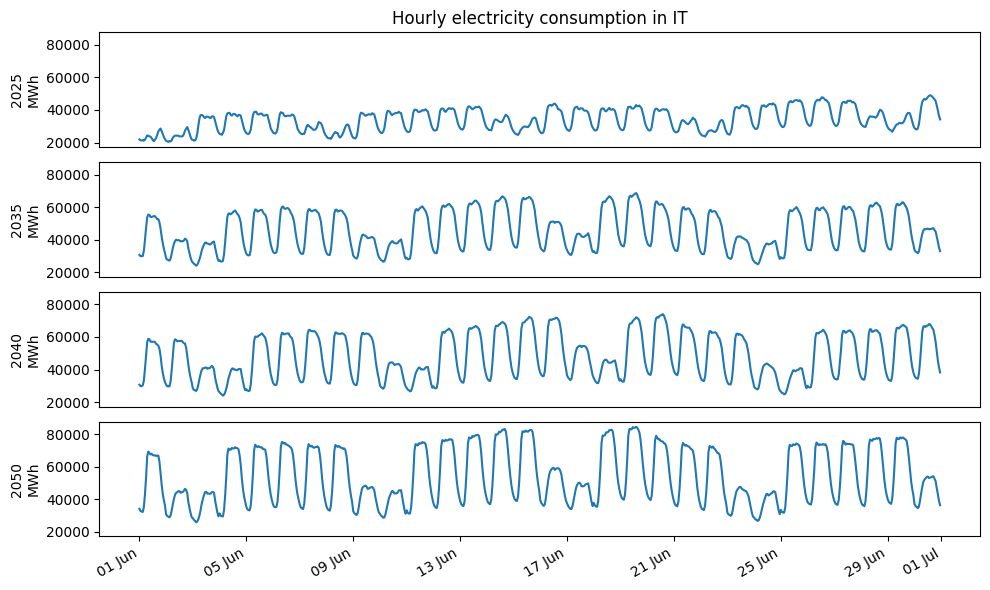

In [10]:
country_to_inspect = "IT"
to_plot = pd.concat({year:elec_noon_june.results(year)["consumption_volume"]
        .sel(consumer_country=country_to_inspect)
        .to_series() for year in years}, axis=1)

fig, axes = plt.subplots(4,1, figsize=(10,6), sharey=True)

for year, ax in zip(years, axes.flatten()):
    to_plot[year].plot(ax=ax)
    ax.set_xlabel(None)
    ax.set_ylabel(f"{year}\nMWh")
    if ax == axes[-1]:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    else:
        ax.set_xticks([])
    
axes[0].set(
    title=f"Hourly electricity consumption in {country_to_inspect}",
    xlabel="",
)
plt.tight_layout()

### Wind check

This specifically checks the Italian offshore-wind, which does not exist in ecoinvent and therefore cannot be mapped directly to `electricity production, wind, 1-3MW turbine, offshore {IT}` (many similar cases can be found for other countries), and should fall back to the right IAM region, first in the solved volume data and then in the mapped premise table.

We can see in the next cell that Italy has a substantial production of offshore wind.

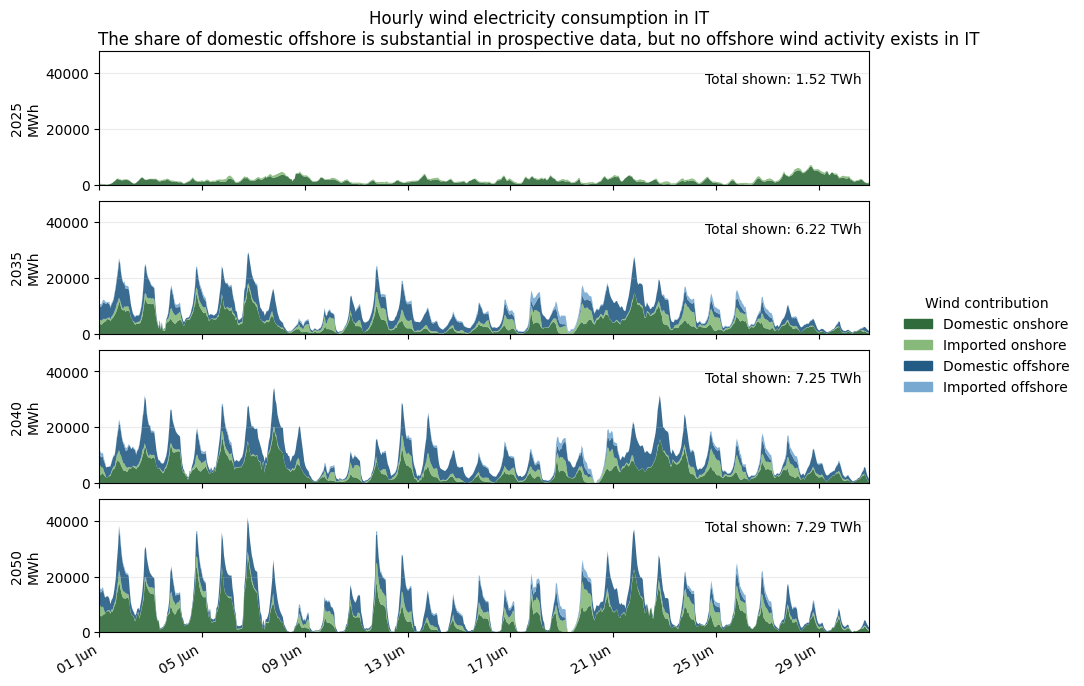

In [11]:
wind_technologies = [
    technology
    for technology in set.union(*[set(elec_noon_june.results(year).coords["technology"].values) for year in years])
    if "wind" in str(technology).lower()
]

if wind_technologies:
    wind_volume_by_year = {}
    for year in years:
        available_technologies = sorted(
            set(elec_noon_june.results(year).coords["technology"].values)
            & set(wind_technologies)
        )
        wind_volume = (
            elec_noon_june.results(year)["consumption_mix_volume"]
            .sel(
                consumer_country=country_to_inspect,
                technology=available_technologies,
            )
            .to_series()
            .unstack(["technology", "source_country"])
            .fillna(0)
        )

        def category_volume(*, offshore, domestic):
            columns = [
                (technology, source_country)
                for technology, source_country in wind_volume.columns
                if ("offshore" in str(technology).lower()) == offshore
                and (str(source_country) == str(country_to_inspect)) == domestic
            ]
            return wind_volume[columns].sum(axis=1)

        wind_volume_by_year[year] = pd.DataFrame(
            {
                "Domestic onshore": category_volume(offshore=False, domestic=True),
                "Imported onshore": category_volume(offshore=False, domestic=False),
                "Domestic offshore": category_volume(offshore=True, domestic=True),
                "Imported offshore": category_volume(offshore=True, domestic=False),
            }
        )

    colors = {
        "Domestic onshore": "#2F6B3B",
        "Imported onshore": "#86B97A",
        "Domestic offshore": "#245B85",
        "Imported offshore": "#77A9D1",
    }
    maximum_hourly_wind = max(
        wind_volume.sum(axis=1).max()
        for wind_volume in wind_volume_by_year.values()
    )
    shared_ymax = maximum_hourly_wind * 1.15 if maximum_hourly_wind > 0 else 1
    fig, axes = plt.subplots(
        len(years),
        1,
        figsize=(11, 7),
        sharey=True,
        squeeze=False,
    )
    axes = axes[:, 0]

    for position, (year, ax) in enumerate(zip(years, axes)):
        wind_volume = wind_volume_by_year[year]
        wind_volume.plot.area(
            ax=ax,
            stacked=True,
            color=colors,
            alpha=0.9,
            linewidth=0,
            legend=False,
            x_compat=True,
        )
        total_volume = wind_volume.sum().sum()
        ax.text(
            0.99,
            0.84,
            f"Total shown: {total_volume / 1e6:.2f} TWh",
            transform=ax.transAxes,
            ha="right",
            va="top",
        )
        ax.set(xlabel="", ylabel=f"{year}\nMWh")
        ax.set_ylim(0, shared_ymax)
        ax.margins(x=0)
        ax.grid(axis="y", alpha=0.25)
        if position == len(axes) - 1:
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
        else:
            ax.tick_params(axis="x", labelbottom=False)

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=color, label=technology)
        for technology, color in colors.items()
    ]
    fig.legend(
        handles=legend_handles,
        title="Wind contribution",
        loc="center left",
        bbox_to_anchor=(0.82, 0.5),
        frameon=False,
    )
    fig.suptitle(f"Hourly wind electricity consumption in {country_to_inspect}\nThe share of domestic offshore is substantial in prospective data, but no offshore wind activity exists in {country_to_inspect}")
    fig.subplots_adjust(left=0.1, right=0.8, top=0.92, bottom=0.09, hspace=0.12)
else:
    print("No wind technology label was found in the solved result.")

## Inspect the mapped database table

Rows are premise or ecoinvent activities at their selected exchange geography. Columns are consuming countries. The table is already temporally filtered and has the configured cutoff applied.

In [12]:
# Here we should see the offshore wind mapping against the correct activity in region "ESC" (remind-eu geomap for "IT") instead of "IT"
database_table = elec_noon_june.table(year_to_inspect)
display(database_table.sort_values(country_to_inspect, ascending=False).head(5))

column_totals = database_table.sum(axis=0)
display(column_totals.rename("exchange sum").to_frame().head())
np.testing.assert_allclose(column_totals, 1, atol=1e-8)

AT  \
geography activityName                                       product                   unit        
IT        electricity production, photovoltaic, 570kWp op... electricity, low voltage  kWh   0.0   
          electricity production, hydro, run-of-river        electricity, high voltage kWh   0.0   
          electricity production, photovoltaic, 3kWp slan... electricity, low voltage  kWh   0.0   
          electricity production, photovoltaic, 3kWp slan... electricity, low voltage  kWh   0.0   
          electricity production, natural gas, combined c... electricity, high voltage kWh   0.0   

                                                                                              BE  \
geography activityName                                       product                   unit        
IT        electricity production, photovoltaic, 570kWp op... electricity, low voltage  kWh   0.0   
          electricity production, hydro, run-of-river        electricity, high voltage kWh   0.0   
          electricity production, photovoltaic, 3kWp slan... electricity, low voltage  kWh   0.0   
          electricity production, photovoltaic, 3kWp slan... electricity, low voltage  kWh   0.0   
          electricity production, natural gas, combined c... electricity, high voltage kWh   0.0   

                                                                                                   CH  \
geography activityName                                       product                   unit             
IT        electricity production, photovoltaic, 570kWp op... electricity, low voltage  kWh   0.003042   
          electricity production, hydro, run-of-river        electricity, high voltage kWh   0.001190   
          electricity production, photovoltaic, 3kWp slan... electricity, low voltage  kWh   0.000000   
          electricity production, photovoltaic, 3kWp slan... electricity, low voltage  kWh   0.000000   
          electricity production, natural gas, combined c... electricity, high voltage kWh   0.000000   

                                                                                              DE  \
geography activityName                                       product                   unit        
IT        electricity production, photovoltaic, 570kWp op... electricity, low voltage  kWh   0.0   
          electricity production, hydro, run-of-river        electricity, high voltage kWh   0.0   
          electricity production, photovoltaic, 3kWp slan... electricity, low voltage  kWh   0.0   
          electricity production, photovoltaic, 3kWp slan... electricity, low voltage  kWh   0.0   
          electricity production, natural gas, combined c... electricity, high voltage kWh   0.0   

                                                                                              ES  \
geography activityName                                       product                   unit        
IT        electricity production, photovoltaic, 570kWp op... electricity, low voltage  kWh   0.0   
          electricity production, hydro, run-of-river        electricity, high voltage kWh   0.0   
          electricity production, photovoltaic, 3kWp slan... electricity, low voltage  kWh   0.0   
          electricity production, photovoltaic, 3kWp slan... electricity, low voltage  kWh   0.0   
          electricity production, natural gas, combined c... electricity, high voltage kWh   0.0   

                                                                                              FR  \
geography activityName                                       product                   unit        
IT        electricity production, photovoltaic, 570kWp op... electricity, low voltage  kWh   0.0   
          electricity production, hydro, run-of-river        electricity, high voltage kWh   0.0   
          electricity production, photovoltaic, 3kWp slan... electricity, low voltage  kWh   0.0   
          electricity production, photovoltaic, 3kWp s

,exchange sum
AT,1.0
BE,1.0
CH,1.0
DE,1.0
ES,1.0


In [13]:
# Check against which region the "offshore wind" activity is being matched
# Only countries with offshore wind in the latest ecoinvent version should be country-matched
exchange_geographies = elec_noon_june.exchange_geography_maps[2035]
offshore_activity_mask = exchange_geographies.index.astype(str).str.contains(
    "offshore", case=False, regex=False
)
display(exchange_geographies.loc[offshore_activity_mask, countries])

source_country,ES,FR,DE,IT,PT,BE,NL,LU,AT,CH
premise_activity,,,,,,,,,,
"electricity production, wind, 1-3MW turbine, offshore",ES,FR,DE,ESC,PT,BE,NL,EWN,EWN,NEN


## Write the Brightway database

Set `write_database = True` in the configuration cell and run the following cell after the checks above pass. Writing is intentionally separate from creation. An existing output database with the same name will be replaced.

In [14]:
if write_database:
    existing_outputs = [
        name for name in elec_noon_june.database_names.values() if name in bd.databases
    ]
    if existing_outputs:
        print(f"Replacing existing output databases: {existing_outputs}")

    started = perf_counter()
    elec_noon_june.write()
    elapsed = perf_counter() - started
    print(f"Wrote {len(elec_noon_june.written_database_names)} database(s) in {elapsed:,.1f} seconds.")
else:
    print("Database write skipped. Set write_database = True when the tables are ready.")

Replacing existing output databases: ['shrecc_june_noon_2025']


100%|██████████| 10/10 [00:00<00:00, 221.68it/s]


10:27:04+0200 [info     ] Vacuuming database            
Using fallback activity:electricity production, at co-generation oil-fired power plant, post, pipeline 200km, storage 1000m, RER for requested geography ESC
Using fallback activity:electricity production, at oil-fired power plant, combined cycle, oxy, pipeline 200km, storage 1000m, RER for requested geography ESC
Using fallback activity:electricity production, solar thermal parabolic trough, 50 MW, RoW for requested geography ESC
Using fallback activity:electricity production, solar tower power plant, 20 MW, RoW for requested geography ESC
Using fallback activity:electricity production, wind, 1-3MW turbine, offshore, RoW for requested geography ESC
Using fallback activity:electricity production, hydro, run-of-river, RoW for requested geography NEN


100%|██████████| 10/10 [00:00<00:00, 176.87it/s]


10:30:43+0200 [info     ] Vacuuming database            
Using fallback activity:electricity production, at co-generation oil-fired power plant, post, pipeline 200km, storage 1000m, RER for requested geography ESC
Using fallback activity:electricity production, at oil-fired power plant, combined cycle, oxy, pipeline 200km, storage 1000m, RER for requested geography ESC
Using fallback activity:electricity production, solar thermal parabolic trough, 50 MW, RoW for requested geography ESC
Using fallback activity:electricity production, solar tower power plant, 20 MW, RoW for requested geography ESC
Using fallback activity:electricity production, wind, 1-3MW turbine, offshore, RoW for requested geography ESC
Using fallback activity:electricity production, hydro, run-of-river, RoW for requested geography NEN


100%|██████████| 10/10 [00:00<00:00, 207.84it/s]


10:34:55+0200 [info     ] Vacuuming database            
Using fallback activity:electricity production, wind, 1-3MW turbine, offshore, RoW for requested geography ESC
Using fallback activity:electricity production, hydro, run-of-river, RoW for requested geography NEN


100%|██████████| 10/10 [00:00<00:00, 351.42it/s]


10:38:16+0200 [info     ] Vacuuming database            
Wrote 4 database(s) in 893.8 seconds.


In [15]:
if elec_noon_june.written_database_names:
    bd.projects.set_current(project_name)
    written = pd.Series(
        {
            year: {
                "database": name,
                "activities": len(bd.Database(name)),
            }
            for year, name in elec_noon_june.written_database_names.items()
        }
    )
    display(pd.DataFrame(written.to_dict()).T.rename_axis("year"))
else:
    print("No database has been written by this NewDatabase instance.")

,database,activities
year,,
2025,shrecc_june_noon_2025,10
2035,shrecc_june_noon_2035,10
2040,shrecc_june_noon_2040,10
2050,shrecc_june_noon_2050,10
